In [2]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
import sys
import scipy.stats as st

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
from scipy.ndimage._filters import uniform_filter1d as uf
%matplotlib widget 

In [2]:
9.35*8+0.1*9

75.7

<KeysViewHDF5 ['lxt_ttc', 'step_value']>
70
setting up properties
dataset prop <functools.cached_property object at 0x7f28e5e51290>
dataset prop <functools.cached_property object at 0x7f28e4fe9090>
dataset prop <functools.cached_property object at 0x7f28dc7e1950>
dataset prop <functools.cached_property object at 0x7f28dc692810>
dataset prop <functools.cached_property object at 0x7f28dc836310>
dataset prop <functools.cached_property object at 0x7f28e5001290>
dataset prop <functools.cached_property object at 0x7f28e503fd90>
dataset prop <functools.cached_property object at 0x7f28dc6adf10>
delay shape (7701,)
61
setting up properties
dataset prop <functools.cached_property object at 0x7f28e500f150>
dataset prop <functools.cached_property object at 0x7f28dc6d5910>
dataset prop <functools.cached_property object at 0x7f28dc8350d0>
dataset prop <functools.cached_property object at 0x7f28dc672310>
dataset prop <functools.cached_property object at 0x7f28e5cc8190>
dataset prop <functools.cached_

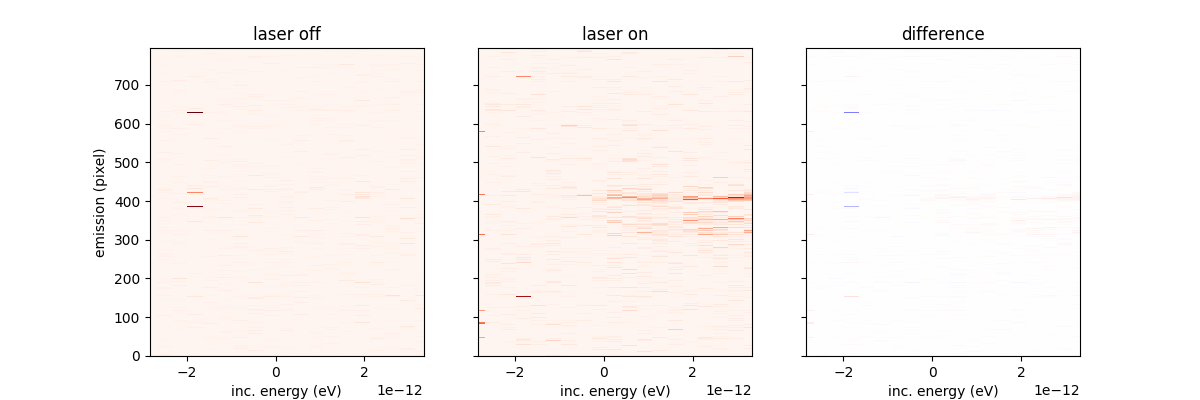

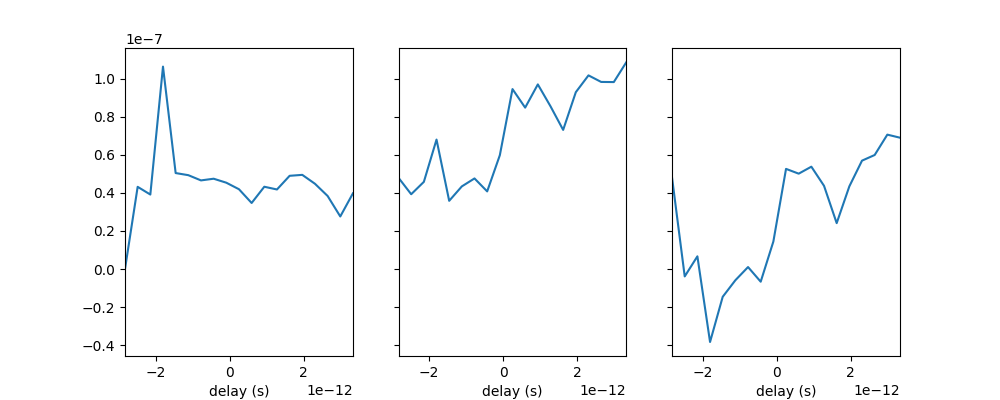

In [30]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'

bgrun = 61
runs=[70]

exp = 'rix101331225'


fyaml = '../roi_inputTT.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= False,norm = True)

avg.plot_svls2D(figsize=(12,4),savefig=False,scale=10)

avg.plot_svls1D(figsize=(10,4),savefig=False)


In [5]:
run = runs[0]

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_inputTT.yml'
bgyaml = '../BGroi_input.yml'

data = SmallData(fname,fyaml)
# bg = SmallData(bgname, bgyaml)

In [6]:
proc = Reduced(fname,bgname,fyaml,bgyaml)

expected_count = st.mode(proc.data.integrating.axis_svls.count, keepdims=False)[0]
mask1 = (proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/proc.data.integrating.axis_svls.count) >0.5

mask2= (proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/expected_count)>0.5
# np.sum(mask1==mask2)
# proc.data.scantype

<KeysViewHDF5 ['lxt_ttc', 'step_value']>
70
setting up properties
dataset prop <functools.cached_property object at 0x7f294835fc90>
dataset prop <functools.cached_property object at 0x7f294835f8d0>
dataset prop <functools.cached_property object at 0x7f29484021d0>
dataset prop <functools.cached_property object at 0x7f2950523810>
dataset prop <functools.cached_property object at 0x7f2948344cd0>
dataset prop <functools.cached_property object at 0x7f2946a5e990>
dataset prop <functools.cached_property object at 0x7f2948395ed0>
dataset prop <functools.cached_property object at 0x7f29484009d0>
delay shape (7701,)
61
setting up properties
dataset prop <functools.cached_property object at 0x7f2965ea3e50>
dataset prop <functools.cached_property object at 0x7f294833f110>
dataset prop <functools.cached_property object at 0x7f2950b46290>
dataset prop <functools.cached_property object at 0x7f295113afd0>
dataset prop <functools.cached_property object at 0x7f295113a4d0>
dataset prop <functools.cached_

In [7]:
# len(proc.data.integrating.axis_svls.delay)
proc.data.integrating


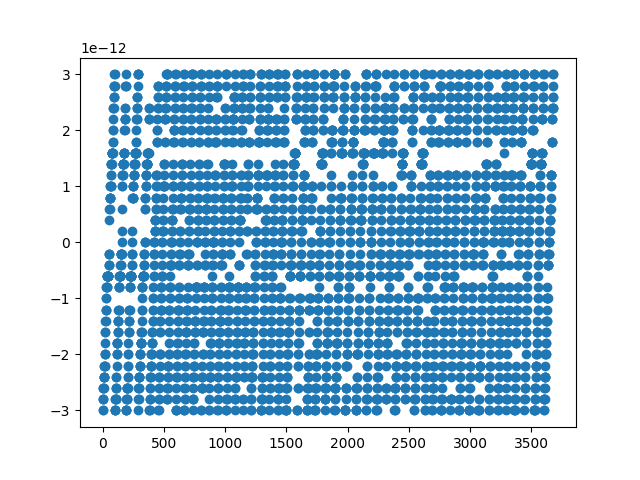

In [8]:
fig,ax=plt.subplots(1,1)
ax.scatter(np.arange(len(proc.data.integrating.axis_svls.delay[mask1])), proc.data.integrating.axis_svls.delay[mask1])

In [9]:
len(proc.data.integrating.axis_svls.delay[mask_on])

NameError: name 'mask_on' is not defined

<KeysViewHDF5 ['lxt_ttc', 'step_value']>
70
setting up properties
dataset prop <functools.cached_property object at 0x7f294694add0>
dataset prop <functools.cached_property object at 0x7f2946949750>
dataset prop <functools.cached_property object at 0x7f29469660d0>
dataset prop <functools.cached_property object at 0x7f294698e510>
dataset prop <functools.cached_property object at 0x7f2946af1f10>
dataset prop <functools.cached_property object at 0x7f294698c350>
dataset prop <functools.cached_property object at 0x7f2950faaa50>
dataset prop <functools.cached_property object at 0x7f294838f310>
delay shape (7701,)


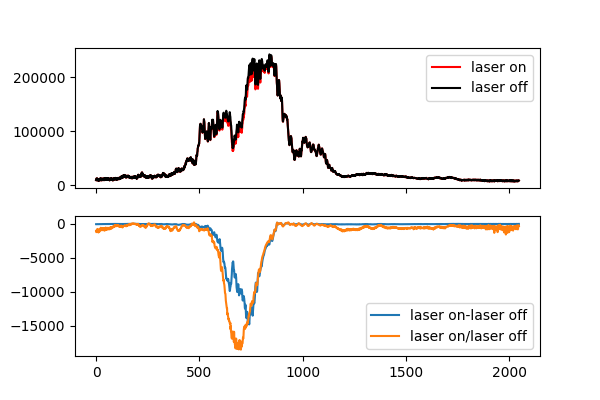

In [10]:

expected_count = st.mode(proc.data.integrating.axis_svls.count, keepdims=False)[0]

data.integrating.axis_svls.piranha.shape
# data.integrating.axis_svls.eventcodes.shape[:,272]
# proc.data.yaml['evc'][True]
mask_on = ((proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][True]]/proc.data.integrating.axis_svls.count) >0.5).squeeze()# (data.integrating.axis_svls.eventcodes[:,272]==1)# np.asarray([data.integrating.axis_svls.eventcodes[:,data.yaml['evc'][True]]/expected_count>0.5]).squeeze()
mask_off = ((proc.data.integrating.axis_svls.eventcodes[:,proc.data.yaml['evc'][False]]/proc.data.integrating.axis_svls.count) >0.5).squeeze() #(data.integrating.axis_svls.eventcodes[:,273]==1)#
piranha = np.flip(proc.data.integrating.axis_svls.piranha)
piranha_on = np.flip(proc.data.integrating.axis_svls.piranha[mask_on,:])
piranha_off = np.flip(proc.data.integrating.axis_svls.piranha[mask_off,:])

fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot(np.nanmean(piranha_on,axis=0).T, 'r',label='laser on')
ax[0].plot(np.nanmean(piranha_off,axis=0).T, 'k',label='laser off')
ax[0].legend()
ax[1].plot((np.nanmean(piranha_on,axis=0))-(np.mean(piranha_off,axis=0)),label='laser on-laser off')
ax[1].plot(((np.nanmean(piranha_on,axis=0))/(np.mean(piranha_off,axis=0))-1)*2e5,label='laser on/laser off')
ax[1].legend()

In [11]:
max_p = -1
ROI=[450,1000]
# u,s,v=np.linalg.svd((piranha_off[1:,:])[:2000,:])

v, s = decomp_((piranha_off[:,:])[:,:],2000) #decomposition of BG data (dark)
traces = decomp_1d(v,s,piranha[:,:],ROI,neigs=2) #all data only ROI

In [16]:
traces[mask_on,:].shape

(6765, 550)

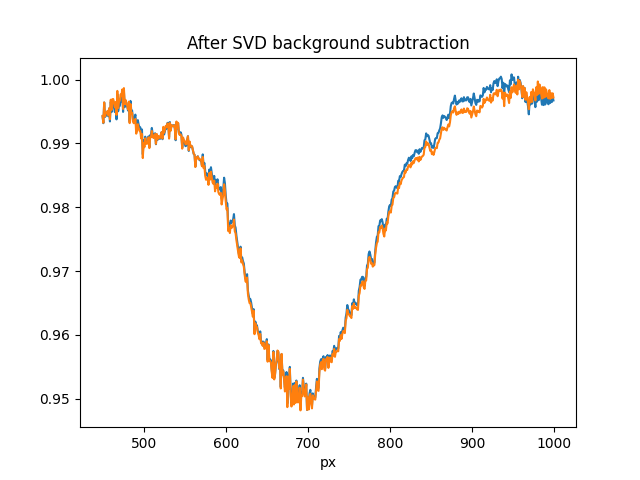

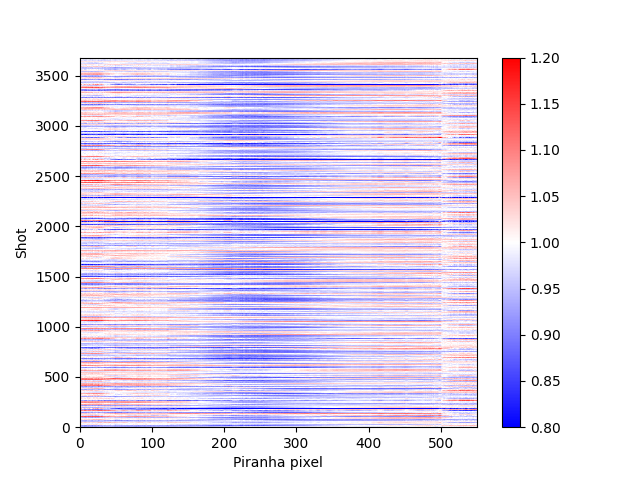

In [12]:


# l = 10

# fig,ax=plt.subplots(1,3,figsize=(10,3))

# for i in np.arange(l):
#     ax[0].plot(u[:,i]+np.max(u)/2*i)
#     ax[0].hlines(np.max(u)/2*i,0,u.shape[0])
# ax[1].scatter(np.arange(10),s[:10])
# for i in np.arange(l):
#     ax[2].plot(v[i,:]+np.max(v)*i/5)

px = np.arange(ROI[0],ROI[1])
plt.figure()
plt.plot(px,np.nanmean(traces[mask_off[:],:],axis =0),label = 'Background')
plt.plot(px,np.nanmean(traces[mask_on[:],:],axis =0),label = 'Signal')
plt.title('After SVD background subtraction')
plt.xlabel('px')
plt.show()
plt.figure()
shots = np.arange(len(traces[mask_on[:]]))
plt.pcolormesh(traces[mask_on[:]],cmap = 'bwr',vmin = 0.8,vmax = 1.2)
plt.xlabel('Piranha pixel')
plt.ylabel('Shot')
plt.colorbar()
plt.show()



In [13]:
ds=uf(np.diff(uf(traces[mask_on[:]],size=1,axis=1,mode='nearest'),axis=1),size=10,axis=1,mode='nearest')
ds.shape

(3681, 549)

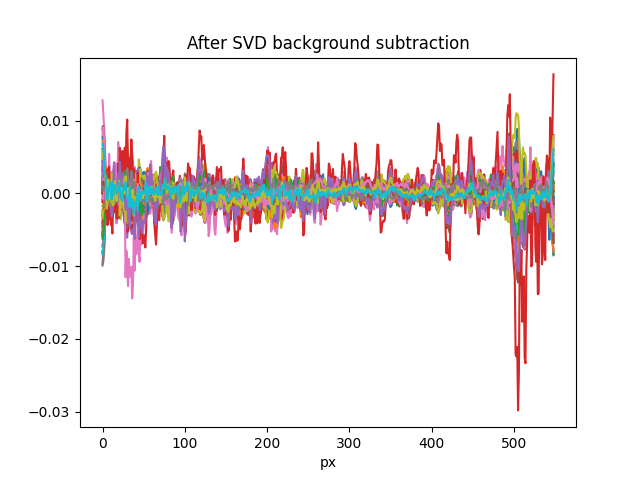

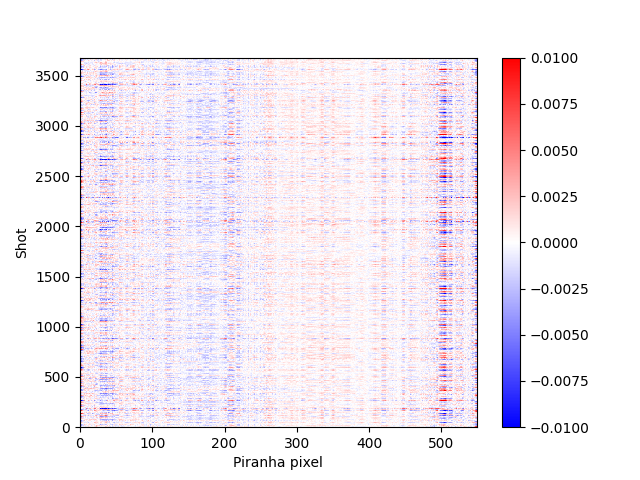

In [14]:

px = np.arange(ROI[0],ROI[1])
plt.figure()
# plt.plot(px,np.nanmean(traces[mask_off[:2000],:],axis =0),label = 'Background')
plt.plot(ds[100:200,:].T,label = 'Signal')
plt.title('After SVD background subtraction')
plt.xlabel('px')
plt.show()
plt.figure()
shots = np.arange(len(ds))
plt.pcolormesh(ds,cmap = 'bwr',vmin=-0.01,vmax=0.01)
plt.xlabel('Piranha pixel')
plt.ylabel('Shot')
plt.colorbar()
plt.show()

In [15]:
def find_edge(y):
    x = np.arange(len(y))
    slopes = np.diff(y)/np.diff(x)
    try:
        p,cov = fit_LS(asymmetric_gaussian,x,y,[1.,x[y==y.max()][0],20,60,7e-5,1e-3])
    except:
        print('FIT FAILED :(') 
        return -9999.0,-9999.0,-9999.0, slopes
    yfit = asymmetric_gaussian(x,*p[:,0])
    slopesfit = np.diff(yfit)/np.diff(x)
    idx = np.where(slopes==slopes.max())[0][0]
    idxfit = np.where(slopesfit==slopesfit.max())[0][0]
    amp = slopesfit[idxfit]
    fwhm = find_fwhm(slopesfit)
    return idxfit,amp,fwhm, slopesfit

In [16]:
def fit_gaussian_fast_linear(x, y, lb, ub):
    tmp = gaussian_moments_linear(x, y)
    p0 = [tmp[0],tmp[1],tmp[2]/2,tmp[2],tmp[3],tmp[4]]
    bounds = [lb, ub]

    if np.any(np.isnan(p0[:3])):
        return p0

    try:
        p0 = np.asarray(p0)
        p0[p0 < lb] = lb[p0 < lb]
        p0[p0 > ub] = ub[p0 > ub]

        popt, _ = curve_fit(
            # gaussian_linear,
            asymmetric_gaussian, #(x, A, mu, sigma1, sigma2,C,D)
            x,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=3000
        )
        return popt
    except RuntimeError:
        return p0

def asymmetric_gaussian(x, A, mu, sigma1, sigma2,C,D):
    return np.where(x < mu,
                    A * np.exp(-((x - mu)**2) / (2 * sigma1**2)),
                    A * np.exp(-((x - mu)**2) / (2 * sigma2**2)))+D*x+C

In [17]:

px = np.arange(ROI[0],ROI[1])
x = px
spectra = -traces[mask_on[:]]
# spectra = np.zeros([10,traces.shape[1]])
# for i in np.arange(10):
#     spectra[i,:] = np.mean(2-traces[mask_on[:2000]][i*100:(i+1)*100,:],axis=0)

spectra.shape == (traces[mask_on[:]].shape[0], traces[mask_on[:]].shape[1])
x.shape == (traces[mask_on[:]].shape[0],)
params = np.array([
    gaussian_moments_linear(x, spectra[i])
    for i in range(spectra.shape[0])
])
lb = np.array([0.,   600,  1, 1,   -1.2, -1])  # A, mu, sigma, C (lower)
ub = np.array([1,   850, 150, 200, -0.8, 1])    
params_fit = np.array([
    fit_gaussian_fast_linear(x, spectra[i],lb,ub)
    for i in range(spectra.shape[0])
])



A     = params[:, 0]
mu    = params[:, 1]
sigma = params[:, 2]
sigma1 = params[:, 2]
A_fit     = params_fit[:, 0]
mu_fit    = params_fit[:, 1]
sigma_fit = params_fit[:, 2]
sigma_fit1 = params_fit[:, 3]

leading_edge_max  = np.array([
                                x[np.argmax(np.diff(asymmetric_gaussian(x, params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4]))/np.diff(x))]
                                for i in np.arange(params.shape[0])
                                ])#mu - sigma
leading_edge_fit_max  = np.array([
                                x[np.argmax(np.diff(asymmetric_gaussian(x, *params_fit[i,:]))/np.diff(x))] 
                                for i in np.arange(params_fit.shape[0])
                                ])#mu - sigma
leading_edge  = mu - sigma
leading_edge_fit  = mu_fit - sigma_fit

# np.savetxt(f"proc/leading_edge{run}.txt", leading_edge)

# np.savetxt(f"proc/leading_edge_fit{run}.txt", leading_edge_fit)


In [39]:
sigma_fit

array([47.79662283, 31.62961579, 47.42854673, ..., 29.05905487,
       96.71818058, 46.98089775])

Text(0.5, 1.0, 'reconstructed from gaussian moment')

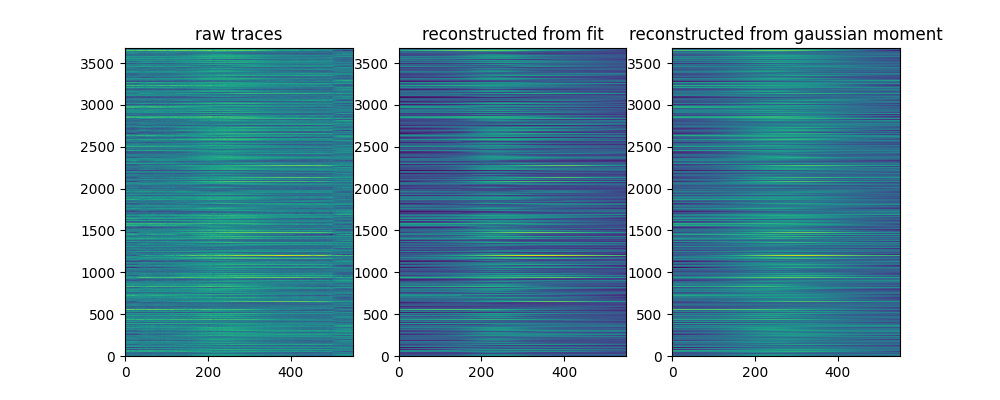

In [18]:
fit = np.array([
    asymmetric_gaussian(x, *params_fit[i,:])
    for i in range(spectra.shape[0])
])

fit_moment = np.array([
    asymmetric_gaussian(x, params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4])
    for i in range(spectra.shape[0])
])

fig,ax=plt.subplots(1,3,figsize=(10,4))
ax[0].pcolor(spectra)
ax[0].set_title('raw traces')
ax[1].pcolor(fit)
ax[1].set_title('reconstructed from fit')
ax[2].pcolor(fit_moment)
ax[2].set_title('reconstructed from gaussian moment')

In [20]:

# np.savetxt(f"proc/leading_edge1{run}.txt", leading_edge)
leading_edge_fit[leading_edge_fit>700]=625
leading_edge_fit[leading_edge_fit<520]=625
leading_edge_fit_max[leading_edge_fit_max>700]=625
leading_edge_fit_max[leading_edge_fit_max<520]=625


np.savetxt(f"proc/leading_edge_{run}.txt", leading_edge_fit)
np.savetxt(f"proc/leading_edge_fit1_diff{run}.txt", leading_edge_fit_max)

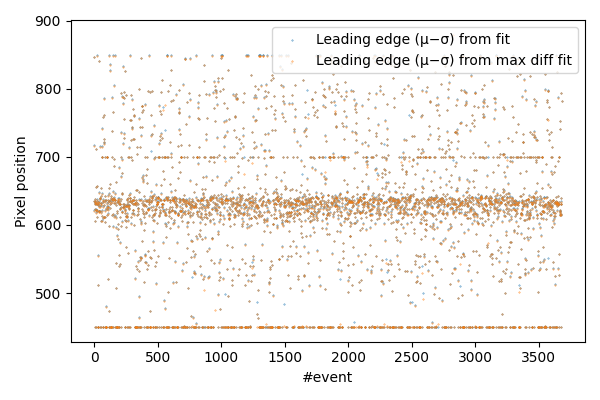

In [19]:
# A     = params[:, 0]
# mu    = params[:, 1]
# sigma = params[:, 2]
# A_fit     = params_fit[:, 0]
# mu_fit    = params_fit[:, 1]
# sigma_fit = params_fit[:, 2]

# leading_edge  = mu - sigma
# leading_edge_fit  = mu_fit - sigma_fit
# # trailing_edge = mu + sigma

idx = np.arange(len(leading_edge))  # curve index, delay index, shot index, etc.

plt.figure(figsize=(6,4))
# plt.scatter(idx, leading_edge, s=.5, label="Leading edge (μ−σ) from gaussian mode")
plt.scatter(idx, leading_edge_fit, s=.1, label="Leading edge (μ−σ) from fit")
# plt.scatter(idx, leading_edge_max, s=.1, label="Leading edge (μ−σ) from max diff gaussian mode")
plt.scatter(idx, leading_edge_fit_max, s=.1, label="Leading edge (μ−σ) from max diff fit")
# plt.plot(idx, leading_edge_fit-leading_edge, label="difference leading edge ")
# plt.scatter(idx, trailing_edge, s=5, label="Trailing edge (μ+σ)")
plt.xlabel("#event")
plt.ylabel("Pixel position")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
np.mean((leading_edge_fit_max-800)*5*1e-15)

-9.83156416321703e-13

Text(0, 0.5, 'edge position')

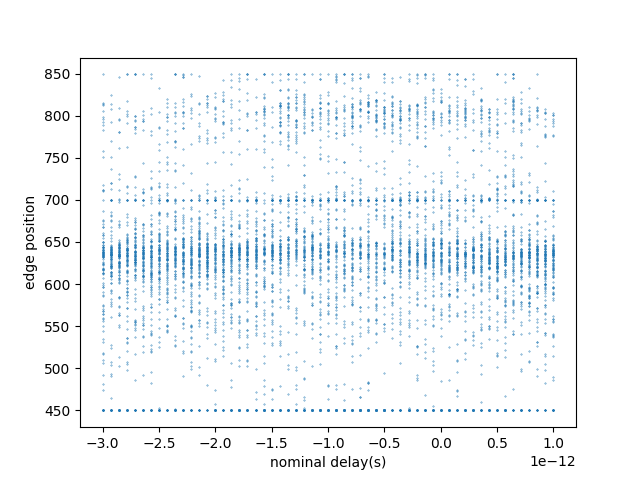

In [28]:
fig,ax=plt.subplots(1,1)
ax.scatter(data.integrating.axis_svls.delay[:][mask_on[:]],leading_edge_fit,s=0.1)
ax.set_xlabel('nominal delay(s)')
ax.set_ylabel('edge position')

In [34]:
params[:,0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

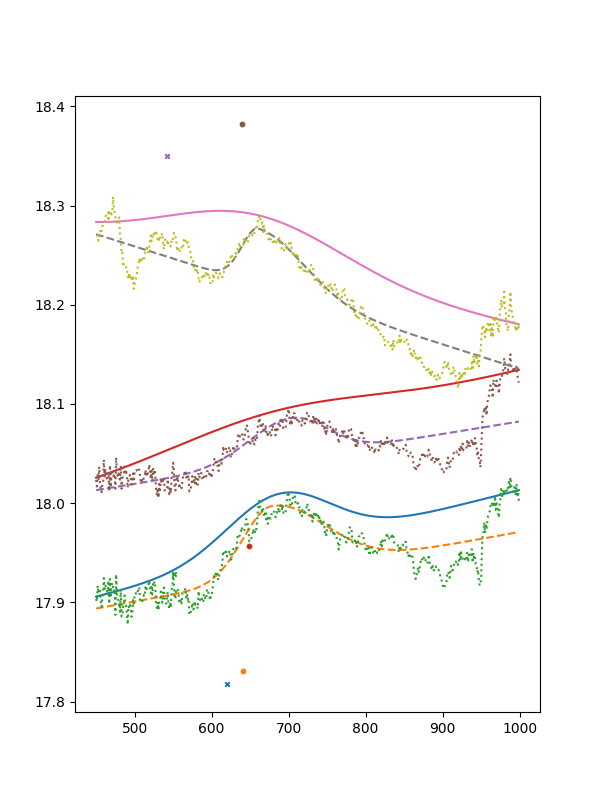

In [32]:
fig,ax =plt.subplots(1,1,figsize=(6,8))
f=1
for i in np.arange(153,156,1):
    ax.plot(px,asymmetric_gaussian(px,params[i,0], params[i,1], params[i,2], params[i,2], params[i,3], params[i,4])+params[0,0]*i*f)
    ax.plot(px,asymmetric_gaussian(px,*params_fit[i,:])+params[0,0]*i*f,'--')
    ax.plot(px,spectra[i]+params[0,0]*i*f,':')
    ax.scatter(leading_edge[i],params[0,0]*i*f+params[i,-2],s=10,marker='x')
    ax.scatter(leading_edge_fit[i],params[0,0]*i*f+params_fit[i,-2],s=10,marker='o')

In [44]:
45*5

225

In [9]:
ROI=[900,1400]
# u,s,v=np.linalg.svd((piranha_off[1:,:])[:1000,:])

v, s = decomp_((piranha_off[1:,:])[:,:],2000) #decomposition of BG data (dark)
traces_decomp = decomp_1d(v,s,data.integrating.axis_svls.piranha,ROI) #all data only ROI

NameError: name 'random' is not defined

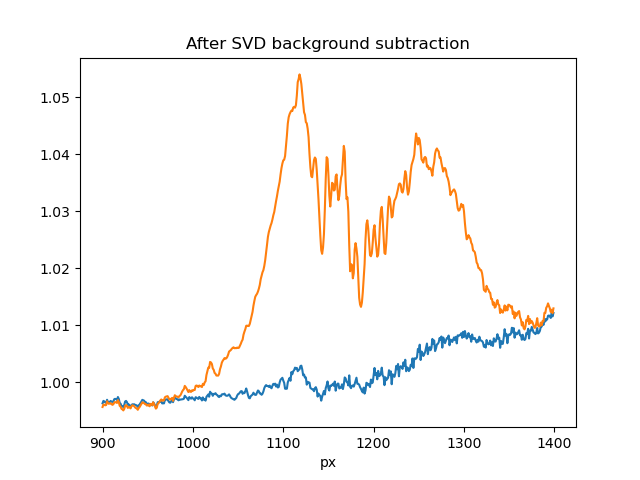

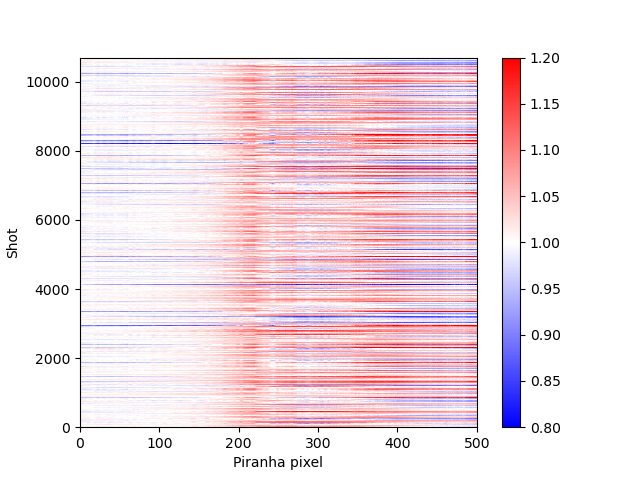

In [ ]:


# l = 10

# fig,ax=plt.subplots(1,3,figsize=(10,3))

# for i in np.arange(l):
#     ax[0].plot(u[:,i]+np.max(u)/2*i)
#     ax[0].hlines(np.max(u)/2*i,0,u.shape[0])
# ax[1].scatter(np.arange(10),s[:10])
# for i in np.arange(l):
#     ax[2].plot(v[i,:]+np.max(v)*i/5)

px = np.arange(ROI[0],ROI[1])
plt.figure()
plt.plot(px,np.nanmean(traces[mask_off,:],axis =0),label = 'Background')
plt.plot(px,np.nanmean(traces[mask_on,:],axis =0),label = 'Signal')
plt.title('After SVD background subtraction')
plt.xlabel('px')
plt.show()
plt.figure()
shots = np.arange(len(traces[mask_on]))
plt.pcolormesh(traces[mask_on],cmap = 'bwr',vmin = 0.8,vmax = 1.2)
plt.xlabel('Piranha pixel')
plt.ylabel('Shot')
plt.colorbar()
plt.show()



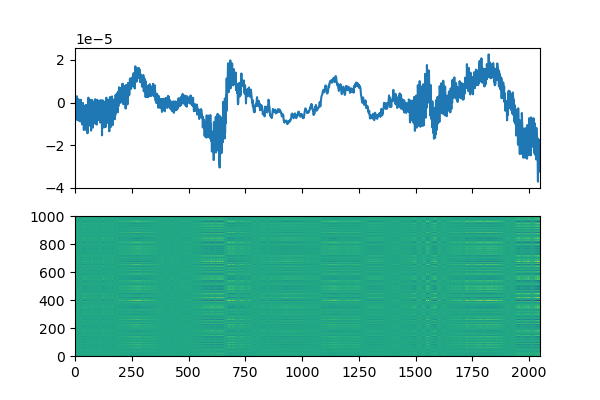

In [59]:
ind_comp = reconst_singlecomp(u,s,v,10)


noise_free = reconst_svd(u,s,v,9) 


fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot(np.mean(ind_comp,axis=0))

ax[1].pcolor(ind_comp)

In [ ]:


noise_free = reconst_svd(u,s,v,9) 

piranha_on_nf = noise_free[mask_on,:]
piranha_off_nf = noise_free[mask_off,:]

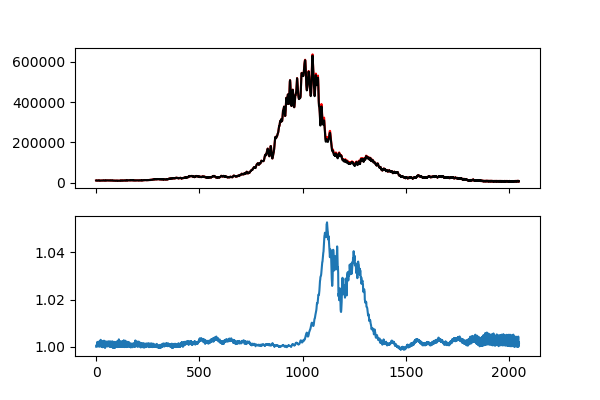

In [39]:
# pir_bg = np.mean(u[:,0])*s[0]*v[0,:]

fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot(np.nanmean(piranha_on_nf,axis=0).T, 'r')
ax[0].plot(np.nanmean(piranha_off_nf,axis=0).T, 'k')
# ax[0].plot(pir_bg,linewidth=0.5)
ax[1].plot((np.nanmean(piranha_on_nf,axis=0))/(np.mean(piranha_off_nf,axis=0)))
# ax[1].plot((np.nanmean(piranha_on_nf[:,900:1500],axis=0))/pir_bg)

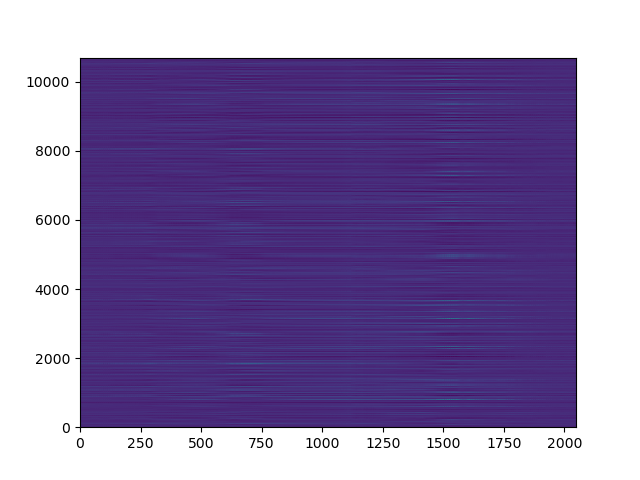

In [33]:
fig,ax=plt.subplots(1,1)

ax.pcolor(((piranha_on_nf)/(piranha_off_nf[1:,:])))

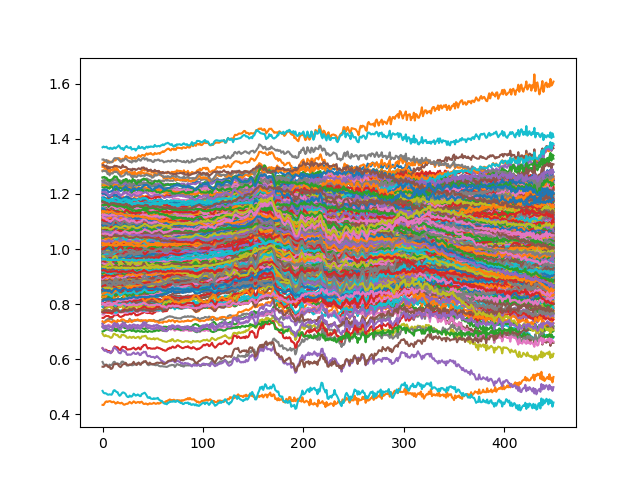

In [50]:
fig,ax=plt.subplots(1,1)

ax.plot((piranha_on/pir_bg)[:500,950:1400].T)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,3))
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,272]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,272]==1],color='r',s=2,label='laser on')
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,273]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,273]==1],color='k',s=2,label='laser off')
ax.legend()
ax.set_xlim([0,len(data.integrating.axis_svls.mono)])
# fig.savefig('figs/mono_move_onoff.png',dpi=200,bbox_inches='tight')


In [ ]:
for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True)



avg=avg_data(runs,proc_folder)

In [ ]:
red.data.integrating.axis_svls.mono.max()

In [ ]:
fig,ax=plt.subplots()
ax.plot(np.nansum(red.data.integrating.axis_svls.full_area,axis=0),'k',label='data')
ax.plot(np.nansum(red.bg.integrating.axis_svls.full_area,axis=0),'r',alpha=0.5,label='background')
ax.legend()
# ax.plot(np.nansum(red.proc,axis=0),'k')
# ax.plot(np.nansum(red.proc.svls,axis=0),'r')

In [ ]:
fig,ax=plt.subplots(1,1)
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1)-np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_off,np.sum(red.axis_svls_off_mean,1))
# ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(9,3),sharex=True,sharey=True)
ax[0].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_off_sum']))
ddat=np.nanmax(np.abs(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='RdBu')
ax[0].set_xlim([avg['scanvar_off'].min(),avg['scanvar_off'].max()])

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

# if emi_calib == []:
#     if data.runinfo == 'mono':
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            dat=avg['axis_svls_sum'], 
            mono = avg['scanvar'], 
            calib=emi_calib, 
                points = points)
#     else:
#         print('need mono scan to calibrate using emission axis')
# else:
#     emi,calib =pixel2emi(np.arange(avg['axis_svls_sum'].shape[1]), mono=[],
#                     dat=avg['axis_svls_sum'], 
#                     calib=emi_calib) 
                    
# if data.runinfo == 'mono':
mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
# else:
#     E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

if emi_calib == []:
    if data.scantype == 'mono':
        emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    mono = avg['scanvar_on'], 
                    calib=emi_calib, 
                    points = points)
    else:
        print('need mono scan to calibrate using emission axis')
else:
    emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    calib=emi_calib) 
                    
if data.scantype == 'mono':
    mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
    mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)
else:
    E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



In [ ]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [6]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=84
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['axis_svls'].keys()
# test1['scan']['lxt_ttc']

<KeysViewHDF5 ['c_piranha_sum_full_area', 'count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_dense_curve_corr_pj_ax_1_data', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

In [ ]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

In [ ]:

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    h5dump(tmp)


In [18]:

with h5py.File(fname,'r') as file:
    print(np.prod(file['intg']['axis_svls']['droplet_dense_curve_corr_pj_ax_1_data'][:1000].shape))

796000


0.6761368265202949


"\n    test_ims_thresh = file['intg/axis_svls/curve_corr_corrected_image'][:20,:][...]\n    test_los_thresh = file['intg/axis_svls/curve_corr_pj_ax_1_data'][:,:][...]\n\n\n\nplt.figure()\nplt.subplot(211)\nplt.plot(np.nanmean(test_los_thresh,axis =0),label = 'curve_corr_pj_ax_1_data')\nplt.legend()\nplt.subplot(212)\nplt.plot(np.nanmean(test_ims_thresh,axis =(0,2)),label = 'lineout from curve_corr_corrected_image')\nplt.xlabel('pixel')\n# Plt.legend()\nplt.show()\n"

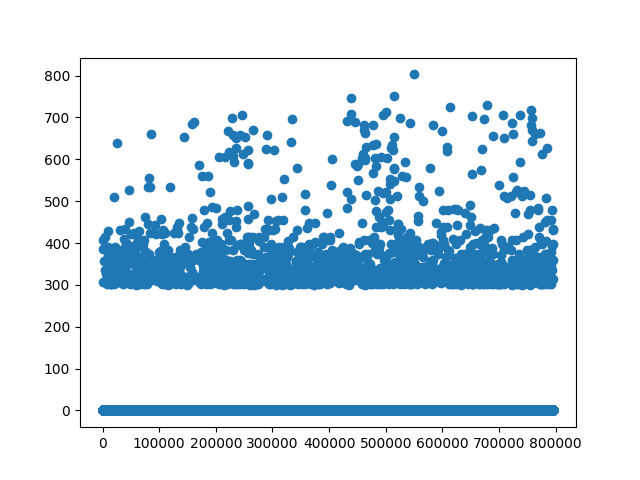

In [19]:

import dask.array as da
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0066.h5'
fig,ax=plt.subplots(1,1)

with h5py.File(fname,'r') as file:
    print(np.nanmean(file['intg']['axis_svls']['droplet_dense_curve_corr_pj_ax_1_data']))
    # test=da.from_array(file['intg']['axis_svls']['det_crix_w8_sum_full_area'], chunks = 'auto')
    ax.scatter(np.arange(np.prod(file['intg']['axis_svls']['droplet_dense_curve_corr_pj_ax_1_data'][:1000].shape)),file['intg']['axis_svls']['droplet_dense_curve_corr_pj_ax_1_data'][:1000])
    # fh = h5py.File(fname, 'r')

'''
    test_ims_thresh = file['intg/axis_svls/curve_corr_corrected_image'][:20,:][...]
    test_los_thresh = file['intg/axis_svls/curve_corr_pj_ax_1_data'][:,:][...]



plt.figure()
plt.subplot(211)
plt.plot(np.nanmean(test_los_thresh,axis =0),label = 'curve_corr_pj_ax_1_data')
plt.legend()
plt.subplot(212)
plt.plot(np.nanmean(test_ims_thresh,axis =(0,2)),label = 'lineout from curve_corr_corrected_image')
plt.xlabel('pixel')
# Plt.legend()
plt.show()
'''

In [10]:
test_ims_thresh.sum()

0.0

In [32]:

# with h5py.File('proc/Run0065_bothbound.h5','r') as f:
#     t_no = np.asarray(f['scanvar_on'])
#     dat_on_no = np.asarray(f['axis_svls_on_mean'])
#     dat_off_no = np.asarray(f['axis_svls_off_mean'])
 
with h5py.File(f'proc/Run0070.h5','r') as f:
    t_fit = np.asarray(f['scanvar_on'])
    dat_on_fit = np.asarray(f['axis_svls_on_mean'])
    dat_off_fit = np.asarray(f['axis_svls_off_mean'])

with h5py.File('proc/Run0070_nocorr.h5','r') as f:
    t_gaus = np.asarray(f['scanvar_on'])
    dat_on_gaus = np.asarray(f['axis_svls_on_mean'])
    dat_off_gaus = np.asarray(f['axis_svls_off_mean'])


(-2e-12, 2e-12)

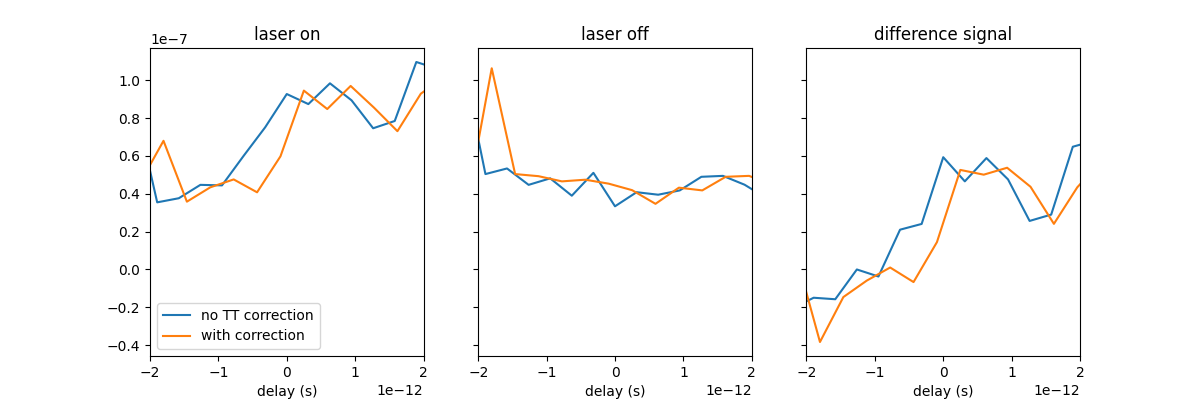

In [42]:
fig,ax = plt.subplots(1,3,sharex=True, sharey=True,figsize=(12,4))
# ax[0].plot(t_no,np.nanmean(dat_on_no,axis=1),label='no correction')
ax[0].plot(t_gaus,np.nanmean(dat_on_gaus,axis=1),label='no TT correction')
ax[0].plot(t_fit,np.nanmean(dat_on_fit,axis=1),label = 'with correction')
ax[0].legend()
ax[0].set_title('laser on')
# ax[1].plot(t_no,np.nanmean(dat_off_no,axis=1))
ax[1].plot(t_gaus,np.nanmean(dat_off_gaus,axis=1))
ax[1].plot(t_fit,np.nanmean(dat_off_fit,axis=1))
ax[1].set_title('laser off')
# ax[2].plot(t_no,np.nanmean(dat_on_no-dat_off_no,axis=1))
ax[2].plot(t_gaus,np.nanmean(dat_on_gaus-dat_off_gaus,axis=1))
ax[2].plot(t_fit,np.nanmean(dat_on_fit-dat_off_fit,axis=1))
# ax[2].hlines(0,-2,2,'k')
ax[2].set_title('difference signal')

ax[0].set_xlabel('delay (s)')
ax[1].set_xlabel('delay (s)')
ax[2].set_xlabel('delay (s)')
ax[0].set_xlim([-2e-12,2e-12])

